# AGL — RoBERTa Fine-Tuning for Prompt Classification

**Adaptive Guardrail Layer (AGL) — Multi-Stage Neural Classifier for LLM Security**

This notebook fine-tunes `roberta-base` on the AGL 4-class dataset (Benign, Injection, Jailbreak, Exfiltration) using a T4 GPU on Google Colab.

**Runtime:** GPU → T4 (Colab free tier) or better

In [1]:
# ── 1. Setup ────────────────────────────────────────────────────────────────
# Clone/update the repo

import os, sys
REPO_DIR = '/content/agl-capstone'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/joeldiev/aai-590-group-8-capstone.git {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Cloning into '/content/agl-capstone'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 97 (delta 34), reused 83 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 910.31 KiB | 25.29 MiB/s, done.
Resolving deltas: 100% (34/34), done.
Working directory: /content/agl-capstone


In [2]:
# ── 2. Install dependencies ─────────────────────────────────────────────────
!pip install -r requirements.txt -q
!pip install wandb -q  # optional: experiment tracking

# Verify GPU
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Log in to HuggingFace (required for gated datasets: hackaprompt, wildguardmix)
# Get a token at https://huggingface.co/settings/tokens (read access is sufficient)
from huggingface_hub import login
login()

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Step 3: Build Dataset

Run the data pipeline to download, merge, label, deduplicate, balance, and split the dataset.

- `--phase mvp` → 3-class (Benign, Injection, Jailbreak) using deepset + JailBreakV-28K only
- `--phase full` → 4-class (adds Exfiltration) with all sources + synthetic data

In [12]:
# ── 3. Build dataset ────────────────────────────────────────────────────────
# Change to "full" once all datasets and synthetic exfiltration are ready
!python -m src.run --stage data --phase full


Building AGL dataset — phase=full

Loading deepset...
  → 662 samples
Loading jailbreakv28k...
  → 28000 samples
Loading hackaprompt...
hackaprompt.parquet: 100% 150M/150M [00:03<00:00, 43.0MB/s]
Generating train split: 100% 601757/601757 [00:10<00:00, 56196.39 examples/s]
  → 77936 samples
Loading wildguardmix...
  ✗ Failed: 403 Client Error. (Request ID: Root=1-69b7344b-4451a222037ffceb3b710d54;9ad4dc25-003f-433c-94f3-f04cead8ed1f)

Cannot access gated repo for url https://huggingface.co/datasets/allenai/wildguardmix/resolve/main/train/wildguard_train.parquet.
Access to dataset allenai/wildguardmix is restricted and you are not in the authorized list. Visit https://huggingface.co/datasets/allenai/wildguardmix to ask for access.
Loading awesome_chatgpt...
  → 1464 samples
Loading synthetic exfiltration...
[synthetic] Tier 2 CSV not found at /content/agl-capstone/data/processed/synthetic_exfiltration.csv — skipping
[synthetic] Total exfiltration samples: 60

Merged: 108122 total sampl

In [13]:
# ── 3b. Verify dataset ──────────────────────────────────────────────────────
import pandas as pd

for split in ['train', 'val', 'test']:
    df = pd.read_parquet(f'data/processed/{split}.parquet')
    print(f"\n{split}: {len(df)} samples")
    print(df['unified_label'].value_counts().to_string())


train: 11142 samples
unified_label
Jailbreak       4900
Injection       4900
Benign          1300
Exfiltration      42

val: 2388 samples
unified_label
Injection       1050
Jailbreak       1050
Benign           279
Exfiltration       9

test: 2388 samples
unified_label
Injection       1050
Jailbreak       1050
Benign           279
Exfiltration       9


## Step 4: Fine-Tune RoBERTa

Train the classifier with class-weighted cross-entropy, early stopping, and linear LR schedule.

Default hyperparameters (from `src/config.py`):
- LR: 2e-5, warmup: 10%, weight decay: 0.01
- Batch: 16 (gradient accum 2 → effective 32)
- Max epochs: 5, early stopping patience: 2
- Max sequence length: 256

In [14]:
# ── 4. Train RoBERTa classifier ─────────────────────────────────────────────
# Default hyperparameters — override with --lr and --max-length flags
!python -m src.run --stage train --mode classifier

Map: 100% 11142/11142 [00:04<00:00, 2290.36 examples/s]
Tokenized train: 11142 samples
Map: 100% 2388/2388 [00:01<00:00, 2348.73 examples/s]
Tokenized val: 2388 samples
Map: 100% 2388/2388 [00:00<00:00, 2602.29 examples/s]
Tokenized test: 2388 samples
Class weights: [2.142692307692308, 0.568469387755102, 0.568469387755102, 66.32142857142857]
Loading weights: 100% 197/197 [00:00<00:00, 715.87it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISS

## Step 4b: Hyperparameter Experiments (Optional)

Run multiple experiments varying LR and max sequence length. Compare results to pick the best config.

In [15]:
# ── 4b. Hyperparameter sweep (optional) ─────────────────────────────────────
# Results are saved to separate output directories.

import itertools
from src.training.train import train_classifier
from src.config import MODELS_DIR

experiments = {
    'lr': [1e-5, 2e-5, 3e-5],
    'max_length': [128, 256],
}

results = []
for lr, max_len in itertools.product(experiments['lr'], experiments['max_length']):
    name = f"lr{lr}_ml{max_len}"
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"{'='*60}")
    out = MODELS_DIR / f"classifier_{name}"
    try:
        best_path = train_classifier(
            output_dir=out,
            learning_rate=lr,
            max_length=max_len,
        )
        results.append({'lr': lr, 'max_length': max_len, 'path': str(best_path)})
    except Exception as e:
        print(f"  FAILED: {e}")
        results.append({'lr': lr, 'max_length': max_len, 'path': None, 'error': str(e)})

import pandas as pd
pd.DataFrame(results)


Experiment: lr1e-05_ml128


Map:   0%|          | 0/11142 [00:00<?, ? examples/s]

Tokenized train: 11142 samples


Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

Tokenized val: 2388 samples


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved → /content/agl-capstone/models/classifier_lr3e-05_ml256/best


,lr,max_length,path
0,0.00001,128,/content/agl-capstone/models/classifier_lr1e-0...
1,0.00001,256,/content/agl-capstone/models/classifier_lr1e-0...
2,0.00002,128,/content/agl-capstone/models/classifier_lr2e-0...
3,0.00002,256,/content/agl-capstone/models/classifier_lr2e-0...
4,0.00003,128,/content/agl-capstone/models/classifier_lr3e-0...
5,0.00003,256,/content/agl-capstone/models/classifier_lr3e-0...


## Step 5: Fit Anomaly Detector

Extract [CLS] embeddings from the fine-tuned model and fit the Mahalanobis OOD detector.
Threshold is calibrated on the validation set (95% in-distribution recall).

In [16]:
# ── 5. Fit Mahalanobis anomaly detector ─────────────────────────────────────
!python -m src.run --stage train --mode anomaly

Loading weights: 100% 201/201 [00:00<00:00, 522.59it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
Map: 100% 11142/11142 [00:04<00:00, 2652.36 examples/s]
Tokenized train: 11142 samples
Map: 100% 2388/2388 [00:01<00:00, 2357.21 examples/s]
Tokenized val: 2388 samples
Map: 100% 2388/2388 [00:00<00:00, 2708.86 examples/s]
Tokenized test: 2388 samples
Extracting [CLS] embeddings from training set...
Extracting [CLS] embeddings from validation set...
Fitting Mahalanobis detector (PCA → 100 dims)...
[anomaly] Calibrated threshold: 295.1203 (95% ID recall)
[anomaly] Saved detector → /content/agl-capstone/models/anomaly


## Step 6: Evaluate

Run the full evaluation suite: keyword baseline, TF-IDF/SVM baseline, RoBERTa classifier, and (if trained) RoBERTa + anomaly detector.

In [17]:
# ── 6. Run evaluation ───────────────────────────────────────────────────────
!python -m src.run --stage evaluate

Running evaluation suite

[1/3] Keyword blocklist baseline...
  Macro-F1: 0.0975

[2/3] TF-IDF + LinearSVM baseline...
  Macro-F1: 0.9331

[3/3] RoBERTa classifier...
Loading weights: 100% 201/201 [00:00<00:00, 917.70it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
  Macro-F1: 0.9662
Saved results → /content/agl-capstone/results/evaluation_results.json

Summary — Macro-F1 Scores:
  keyword_blocklist         0.0975
  tfidf_svm                 0.9331
  roberta                   0.9662


## Step 7: Visualizations

Generate publication-quality figures: confusion matrix, F1 comparison, ROC curves, latency distribution.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved → /content/agl-capstone/results/figures/confusion_matrix.png
Saved → /content/agl-capstone/results/figures/f1_comparison.png
Latency: mean=16.1ms, p99=17.8ms

All figures saved to: /content/agl-capstone/results/figures


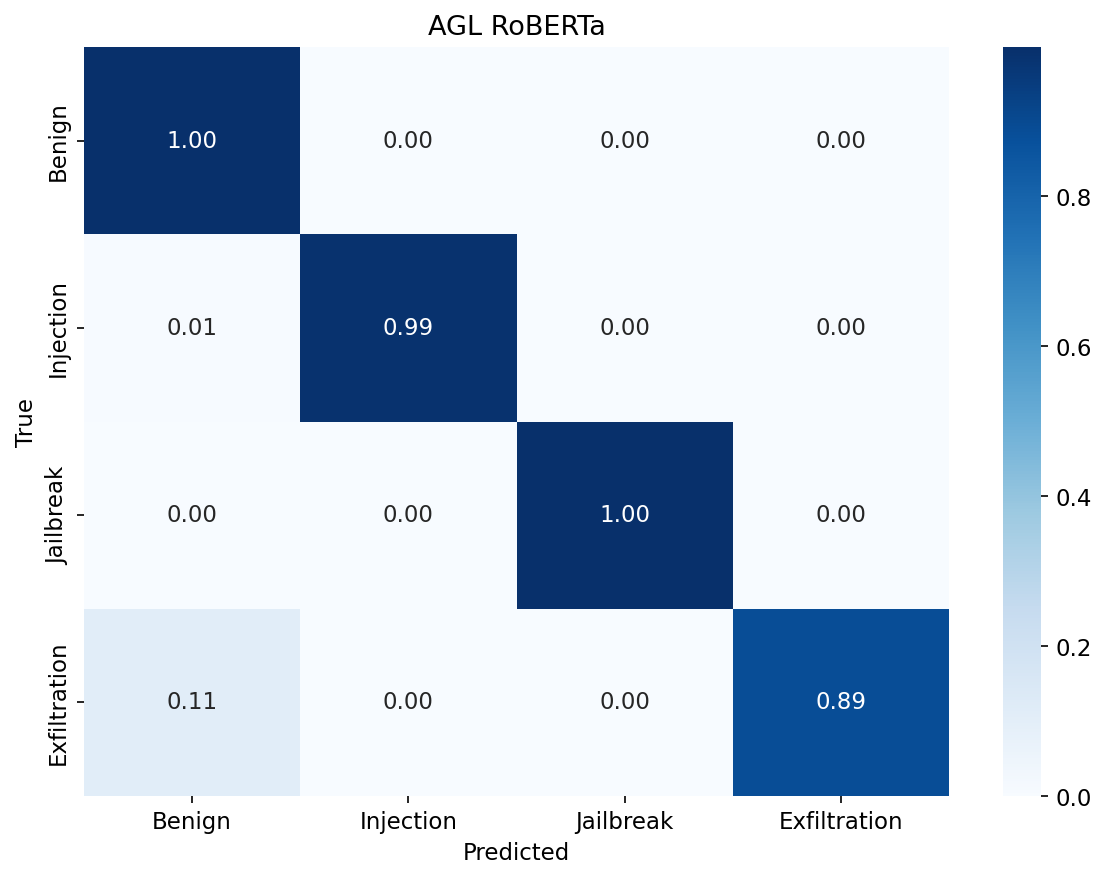

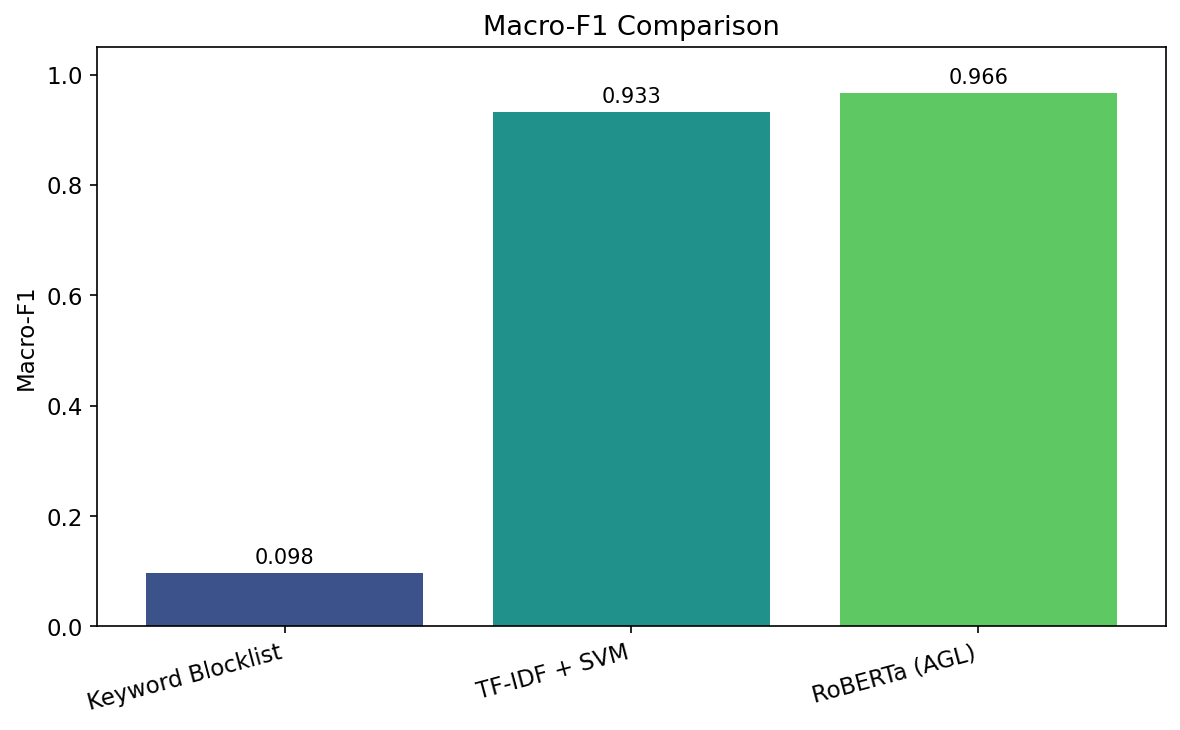

In [18]:
# ── 7. Generate visualizations ──────────────────────────────────────────────
import numpy as np
import pandas as pd
from src.config import RESULTS_DIR, FIGURES_DIR, PROCESSED_DIR, MODELS_DIR
from src.evaluation.visualizations import plot_confusion_matrix, plot_f1_comparison
from src.evaluation.metrics import benchmark_latency
from src.evaluation.baselines import keyword_blocklist_baseline, tfidf_svm_baseline
from src.models.agl_pipeline import AGLPipeline

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load test data
test_df = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
y_true = test_df['label'].values

# Baselines
kw_preds = keyword_blocklist_baseline(test_df)
svm_preds, _ = tfidf_svm_baseline(train_df, test_df)

# RoBERTa predictions
checkpoint = MODELS_DIR / 'classifier' / 'best'
pipeline = AGLPipeline.from_checkpoint(checkpoint)
roberta_preds = np.array([pipeline.predict(t).label_id for t in test_df['text']])

# Confusion matrix
plot_confusion_matrix(y_true, roberta_preds, title='AGL RoBERTa', save_path=FIGURES_DIR / 'confusion_matrix.png')

# F1 comparison
from sklearn.metrics import f1_score
f1_results = {
    'Keyword Blocklist': f1_score(y_true, kw_preds, average='macro', zero_division=0),
    'TF-IDF + SVM': f1_score(y_true, svm_preds, average='macro', zero_division=0),
    'RoBERTa (AGL)': f1_score(y_true, roberta_preds, average='macro', zero_division=0),
}
plot_f1_comparison(f1_results, save_path=FIGURES_DIR / 'f1_comparison.png')

# Latency
latency = benchmark_latency(pipeline, test_df['text'].head(50).tolist(), n_runs=2)
print(f"Latency: mean={latency['mean_ms']:.1f}ms, p99={latency['p99_ms']:.1f}ms")
print('\nAll figures saved to:', FIGURES_DIR)

## Step 8: Save Checkpoint to Drive

Copy the trained model and results to Google Drive for persistence across Colab sessions.

In [19]:
# ── 8. Save to Google Drive ─────────────────────────────────────────────────
import shutil

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/AGL_Capstone'
os.makedirs(DRIVE_DIR, exist_ok=True)

for src, dst_name in [
    ('models/classifier/best', 'classifier_best'),
    ('models/anomaly', 'anomaly'),
    ('results', 'results'),
    ('data/processed', 'data_processed'),
]:
    if os.path.exists(src):
        dst = f'{DRIVE_DIR}/{dst_name}'
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f'Saved {src} -> {dst}')

print('\nDone! All artifacts saved to Google Drive.')

MessageError: Error: credential propagation was unsuccessful